Prepare data train/test

In [1]:
import os
import glob
import numpy as np
import tensorflow as tf
import joblib
import math
import random
from collections import Counter, defaultdict
import pandas as pd # <-- Thêm import

# Thư viện cho việc xử lý dữ liệu
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

2025-09-08 08:09:53.024170: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757318993.194375      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757318993.249424      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [6]:
data_train = ""
data_test = ""

In [1]:
import pandas as pd

def load_split_data_from_excel(excel_path):
    try:
        df_train = pd.read_excel(excel_path, sheet_name='data_train')
        df_test = pd.read_excel(excel_path, sheet_name='data_test')

        data_train_paths = df_train['filepath'].tolist()
        data_test_paths = df_test['filepath'].tolist()
        
        print(f"Đã tải thành công {len(data_train_paths)} đường dẫn cho tập train.")
        print(f"Đã tải thành công {len(data_test_paths)} đường dẫn cho tập test.")
        
        return data_train_paths, data_test_paths

    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy file tại '{excel_path}'")
        return None, None
    except Exception as e:
        print(f"Đã xảy ra lỗi khi đọc file Excel: {e}")
        return None, None


//OrionNet

In [9]:
import os
from glob import glob
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, StratifiedKFold
import joblib

In [10]:
class FreqTemporalCoAttention(layers.Layer):
    """
    A custom layer to learn to focus on important frequency bands and
    time steps within a feature map simultaneously.
    """
    def __init__(self, ratio=8, **kwargs):
        super(FreqTemporalCoAttention, self).__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        # input_shape: (batch, height, width, channels)
        # height ~ frequency, width ~ time
        self.channels = input_shape[-1]
        
        # Neural network for Temporal Attention
        self.temporal_dense1 = layers.Dense(self.channels // self.ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)
        self.temporal_dense2 = layers.Dense(self.channels, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)
        
        # Neural network for Frequency Attention
        self.freq_dense1 = layers.Dense(self.channels // self.ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)
        self.freq_dense2 = layers.Dense(self.channels, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)
        
        super(FreqTemporalCoAttention, self).build(input_shape)

    def call(self, inputs):
        # inputs shape: (batch, freq_bins, time_steps, channels)
        
        # --- Temporal Attention ---
        # Squeeze along the frequency axis -> (batch, time_steps, channels)
        temporal_features = tf.reduce_mean(inputs, axis=1)
        temporal_attention = self.temporal_dense1(temporal_features)
        temporal_attention = self.temporal_dense2(temporal_attention)
        temporal_attention = tf.expand_dims(temporal_attention, axis=1) # (batch, 1, time_steps, channels)

        # --- Frequency Attention ---
        # Squeeze along the time axis -> (batch, freq_bins, channels)
        freq_features = tf.reduce_mean(inputs, axis=2)
        freq_attention = self.freq_dense1(freq_features)
        freq_attention = self.freq_dense2(freq_attention)
        freq_attention = tf.expand_dims(freq_attention, axis=2) # (batch, freq_bins, 1, channels)

        # Recalibrate the original feature map by multiplying with attention weights
        refined_feature_map = inputs * temporal_attention * freq_attention
        
        return refined_feature_map

    def get_config(self):
        config = super().get_config()
        config.update({'ratio': self.ratio})
        return config

In [ ]:
EMO_DB = True

if EMO_DB:
    EMOTIONS = ['Angry', 'Happy', 'Fear', 'Neutral', 'Sad', 'Boredom', 'Disgust']
    NUM_CLASSES = len(EMOTIONS)
    emotion_map = {
        'Angry': 0, 
        'Happy': 1, 
        'Fear': 2, 
        'Neutral': 3, 
        'Sad': 4, 
        'Boredom': 5, 
        'Disgust': 6
    }
    DATA_PATH = '/kaggle/input/speech-emotion-10/EmoDB/EmoDB'
else:
    EMOTIONS = ['Angry', 'Happy', 'Anxiety', 'Neutral', 'Sad']
    NUM_CLASSES = len(EMOTIONS)
    emotion_map = {
        'Angry': 0, 'Happy': 1, 'Anxiety': 2, 'Neutral': 3, 'Sad': 4
    }
    DATA_PATH = '/kaggle/input/speech-emotion-10/VESC/VESC'

# Actual calculation needed from the data
GLOBAL_MEAN_PITCH = 0.0
GLOBAL_JITTER = 0.0
GLOBAL_PITCH_SLOPE = 0.0

# Function to add noise
def add_noise(audio, noise_factor=0.01):
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

# Function to change pitch
def pitch_shift(audio, sr, n_steps=2): # Random n_steps
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)

# Function to apply time stretching
def time_stretch(audio, rate=0.95): # Random rate
    return librosa.effects.time_stretch(audio, rate=rate)

# Function to apply time shifting
def time_shift(audio, shift_max=0.15, sr= 16000):
    shift = int(np.random.uniform(-shift_max, shift_max) * sr)
    return np.roll(audio, shift)

# Function to normalize pitch
def normalize_pitch(pitches):
    pitches = pitches[pitches > 0]
    if len(pitches) == 0:
        return GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE

    mean_pitch = np.mean(pitches)
    normalized_pitches = pitches - mean_pitch
    jitter = np.std(normalized_pitches) if len(normalized_pitches) > 0 else 0

    if len(pitches) > 1:
        slope = np.polyfit(np.arange(len(pitches)), pitches, 1)[0]
    else:
        slope = 0

    if np.isnan(mean_pitch): mean_pitch = GLOBAL_MEAN_PITCH
    if np.isnan(jitter): jitter = GLOBAL_JITTER
    if np.isnan(slope): slope = GLOBAL_PITCH_SLOPE

    return mean_pitch, jitter, slope

# Feature extraction
def extract_features(audio_path, sample_rate= 16000, duration=8, n_mfcc=26, n_frames=157, augment_type='normal', global_pitch_params=None):
    try:
        audio, sr = librosa.load(audio_path, sr=sample_rate)
        target_length = sample_rate * duration

        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)), mode='constant')
        else:
            audio = audio[:target_length]

        if augment_type == 'noise':
            audio = add_noise(audio)
        elif augment_type == 'pitch':
            audio = pitch_shift(audio, sr)
        elif augment_type == 'stretch':
            audio = time_stretch(audio)
        elif augment_type == 'shift':
            audio = time_shift(audio)

        hop_length = target_length // (n_frames - 1)

        # MFCCs + Delta + Delta-Delta
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length, n_fft=2048)
        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
        mfcc_features = np.concatenate((mfcc, mfcc_delta, mfcc_delta2), axis=0)

        # Pad or truncate MFCCs
        if mfcc_features.shape[1] > n_frames:
            mfcc_features = mfcc_features[:, :n_frames]
        elif mfcc_features.shape[1] < n_frames:
            mfcc_features = np.pad(mfcc_features, ((0, 0), (0, n_frames - mfcc_features.shape[1])), mode='constant')

        # Pitch features
        pitches, magnitudes = librosa.piptrack(y=audio, sr=sr, hop_length=hop_length)
        if global_pitch_params:
            mean_pitch, jitter, pitch_slope = normalize_pitch(pitches)
            if mean_pitch == 0 and jitter == 0 and pitch_slope == 0:
                mean_pitch, jitter, pitch_slope = global_pitch_params
        else:
            mean_pitch, jitter, pitch_slope = normalize_pitch(pitches) # Will use current GLOBAL_*

        pitch_features_single = np.array([mean_pitch, jitter, pitch_slope])
        pitch_features = np.tile(pitch_features_single, (n_frames, 1)).T # Tile to match n_frames

        # Energy features (RMS + mean and std)
        energy = librosa.feature.rms(y=audio, hop_length=hop_length)[0]
        if len(energy) > n_frames:
            energy = energy[:n_frames]
        elif len(energy) < n_frames:
            energy = np.pad(energy, (0, n_frames - len(energy)), mode='constant')

        mean_energy = np.mean(energy)
        shimmer = np.std(energy) if len(energy) > 0 else 0
        energy_features = np.array([energy, np.full(n_frames, mean_energy), np.full(n_frames, shimmer)])

        # Zero-Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y=audio, hop_length=hop_length)[0]
        if len(zcr) > n_frames:
            zcr = zcr[:n_frames]
        elif len(zcr) < n_frames:
            zcr = np.pad(zcr, (0, n_frames - len(zcr)), mode='constant')
        zcr_features = zcr[np.newaxis, :]

        # Chroma features
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr, hop_length=hop_length, n_chroma=12)
        if chroma.shape[1] > n_frames:
            chroma = chroma[:, :n_frames]
        elif chroma.shape[1] < n_frames:
            chroma = np.pad(chroma, ((0, 0), (0, n_frames - chroma.shape[1])), mode='constant')

        # Spectral features
        spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr, hop_length=hop_length)[0]
        spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr, hop_length=hop_length)[0]
        spectral_contrast = librosa.feature.spectral_contrast(y=audio, sr=sr, hop_length=hop_length, n_bands=5)

        # Pad or truncate spectral features
        # Assuming all spectral features have the same number of frames
        if spectral_centroid.shape[0] > n_frames:
            spectral_centroid = spectral_centroid[:n_frames]
            spectral_rolloff = spectral_rolloff[:n_frames]
            spectral_contrast = spectral_contrast[:, :n_frames]
        elif spectral_centroid.shape[0] < n_frames:
            spectral_centroid = np.pad(spectral_centroid, (0, n_frames - spectral_centroid.shape[0]), mode='constant')
            spectral_rolloff = np.pad(spectral_rolloff, (0, n_frames - spectral_rolloff.shape[0]), mode='constant')
            spectral_contrast = np.pad(spectral_contrast, ((0, 0), (0, n_frames - spectral_contrast.shape[1])), mode='constant')
        spectral_features = np.vstack([spectral_centroid, spectral_rolloff, spectral_contrast])

        # Temporal features
        voiced_frames = librosa.effects.split(audio, top_db=20)
        speech_rate = len(voiced_frames) / (duration if duration > 0 else 1)
        pauses = len(voiced_frames) - 1 if len(voiced_frames) > 1 else 0
        temporal_features_single = np.array([speech_rate, pauses])
        temporal_features = np.tile(temporal_features_single, (n_frames, 1)).T

        features = np.concatenate([
            mfcc_features, # Now includes delta and delta-delta
            pitch_features,
            energy_features,
            zcr_features,
            chroma,
            spectral_features,
            temporal_features
        ], axis=0)

        return np.expand_dims(features, axis=-1)

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

# Build CNN model
def build_cnn_2d(input_shape=(55, 157, 1)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        FreqTemporalCoAttention(ratio=4),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        FreqTemporalCoAttention(ratio=8),
        layers.Dropout(0.3),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    model.summary()
    return model

# Add a function to calculate GLOBAL_PITCH_PARAMS
def calculate_global_pitch_params(audio_files, sample_rate= 16000): #24200
    all_pitches = []
    for audio_path in audio_files:
        try:
            audio, sr = librosa.load(audio_path, sr=sample_rate)
            pitches, magnitudes = librosa.piptrack(y=audio, sr=sr)
            pitches = pitches[pitches > 0]
            if len(pitches) > 0:
                all_pitches.extend(pitches)
        except Exception as e:
            print(f"Error calculating global pitch for {audio_path}: {e}")
            continue

    if len(all_pitches) == 0:
        print("Warning: No valid pitches found to calculate global parameters. Using default zeros.")
        return 0.0, 0.0, 0.0

    all_pitches = np.array(all_pitches)
    global_mean_pitch = np.mean(all_pitches)

    normalized_all_pitches = all_pitches - global_mean_pitch
    global_jitter = np.std(normalized_all_pitches) if len(normalized_all_pitches) > 0 else 0

    global_pitch_slope = 0.0

    global_mean_pitch = 0.0 if np.isnan(global_mean_pitch) or np.isinf(global_mean_pitch) else global_mean_pitch
    global_jitter = 0.0 if np.isnan(global_jitter) or np.isinf(global_jitter) else global_jitter
    global_pitch_slope = 0.0 if np.isnan(global_pitch_slope) or np.isinf(global_pitch_slope) else global_pitch_slope

    return global_mean_pitch, global_jitter, global_pitch_slope


# Function to prepare data with label mapping from directory
def prepare_training_data(audio_files, emotion_map, global_pitch_params):
    X, y = [], []
    augment_types = ['normal', 'noise', 'pitch', 'stretch', 'shift']
    skipped_files = 0
    processed_files = 0

    print(f"Total number of audio files: {len(audio_files)}")
    for audio_path in audio_files:
        folder_name = os.path.basename(os.path.dirname(audio_path))
        if folder_name not in emotion_map:
            skipped_files += 1
            continue
        emotion_idx = emotion_map[folder_name]

        for aug_type in augment_types:
            features = extract_features(str(audio_path), augment_type=aug_type, global_pitch_params=global_pitch_params)
            if features is None or np.all(features == 0):
                continue
            X.append(features)
            y.append(emotion_idx)
            processed_files += 1

    print(f"Processed: {processed_files} samples, skipped: {skipped_files} files.")
    if not X or not y:
        raise ValueError("No audio files were successfully processed. Please check the data path or emotion_map.")

    X = np.array(X)
    y = to_categorical(y, num_classes=NUM_CLASSES)
    print(f"Dataset shape: X={X.shape}, y={y.shape}")
    return X, y

# Function to prepare test data
def prepare_test_data(audio_files, emotion_map, global_pitch_params):
    X, y = [], []
    skipped_files = 0
    processed_files = 0

    print(f"Total number of test audio files: {len(audio_files)}")
    for audio_path in audio_files:
        folder_name = os.path.basename(os.path.dirname(audio_path))
        if folder_name not in emotion_map:
            skipped_files += 1
            continue
        emotion_idx = emotion_map[folder_name]
        features = extract_features(str(audio_path), augment_type='normal', global_pitch_params=global_pitch_params)
        if features is None or np.all(features == 0):
            continue
        X.append(features)
        y.append(emotion_idx)
        processed_files += 1

    print(f"Processed: {processed_files} samples, skipped: {skipped_files} files.")
    if not X or not y:
        raise ValueError("No test audio files were successfully processed.")

    X = np.array(X)
    y = to_categorical(y, num_classes=NUM_CLASSES)
    print(f"Test dataset shape: X={X.shape}, y={y.shape}")
    return X, y

# Evaluate the model using confusion matrix and F1 Score
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)

    print("\nSample prediction probabilities:")
    for i in range(min(5, len(X_test))):
        print(f"Sample {i+1}: True={EMOTIONS[y_true_classes[i]]}, Pred={EMOTIONS[y_pred_classes[i]]}, Prob={y_pred[i]}")

    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns_heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true_classes, y_pred_classes, target_names=EMOTIONS))

    print("\nEvaluation metric formulas:")
    print("1. Precision = TP / (TP + FP)")
    print("   - TP (True Positives): Number of samples correctly predicted for a class.")
    print("   - FP (False Positives): Number of samples incorrectly predicted as that class.")
    print("2. Recall = TP / (TP + FN)")
    print("   - FN (False Negatives): Number of samples that belong to the class but were incorrectly predicted.")
    print("3. F1 Score = 2 * (Precision * Recall) / (Precision + Recall)")

# Train and evaluate
def train_and_evaluate_model(model, X, y, epochs=200, batch_size=16, checkpoint_path='best_model.h5', class_weight=None, k_folds=5):
    if len(X) == 0 or len(y) == 0:
        raise ValueError("Training dataset is empty. Please check the input data.")

    kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    fold_no = 1
    val_losses = []
    val_accuracies = []
    best_model = None
    best_history = None
    best_val_loss = float('inf')
    X_val_last, y_val_last = None, None
    scaler = StandardScaler()
    y_indices = np.argmax(y, axis=1)
    for train_index, val_index in kf.split(X, y_indices):
        print(f"\nTraining on fold {fold_no}/{k_folds}...")

        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]
        print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}")

        original_shape_train = X_train.shape
        X_train_2d = X_train.reshape(original_shape_train[0], -1)
        
        original_shape_val = X_val.shape
        X_val_2d = X_val.reshape(original_shape_val[0], -1)
        
        X_train_2d = scaler.fit_transform(X_train_2d)
        X_val_2d = scaler.transform(X_val_2d)
        
        X_train = X_train_2d.reshape(original_shape_train)
        X_val = X_val_2d.reshape(original_shape_val)

        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                      loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                      metrics=['accuracy'])

        early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=0.00001)
        checkpoint = ModelCheckpoint(f"{checkpoint_path}_fold_{fold_no}.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)

        history = model.fit(X_train, y_train,
                            validation_data=(X_val, y_val),
                            epochs=epochs,
                            batch_size=batch_size,
                            callbacks=[early_stopping, reduce_lr, checkpoint],
                            class_weight=class_weight,
                            verbose=1)

        val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
        print(f"\nFold {fold_no} - Evaluation on validation set:")
        print(f" - Loss: {val_loss:.4f}")
        print(f" - Accuracy: {val_accuracy:.4f}")
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model
            best_history = history
            X_val_last, y_val_last = X_val, y_val

        fold_no += 1

    print(f"\nAverage results across {k_folds} folds:")
    print(f" - Average Loss: {np.mean(val_losses):.4f}")
    print(f" - Average Accuracy: {np.mean(val_accuracies):.4f}")

    return best_model, best_history, X_val_last, y_val_last

# Direct prediction using CNN
def predict_emotion(audio_path, model, scaler, global_pitch_params):
    features = extract_features(audio_path, augment_type='normal', global_pitch_params=global_pitch_params)
    if features is None or np.all(features == 0):
        return "Prediction failed: Feature extraction error."

    features_2d = features.reshape(1, -1)
    features_2d = scaler.transform(features_2d)
    features = features_2d.reshape(features.shape)

    features = np.expand_dims(features, axis=0)
    prediction = model.predict(features, verbose=0)
    predicted_emotion_idx = np.argmax(prediction, axis=1)[0]

    print(f"Prediction probabilities for {audio_path}: {prediction[0]}")
    return EMOTIONS[predicted_emotion_idx]

# Plot Loss Chart
def plot_loss_history(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


Split data into 474 training files and 61 testing files.
------------------------------
Calculating GLOBAL_PITCH_PARAMS from training data...
GLOBAL_MEAN_PITCH: 1688.6304, GLOBAL_JITTER: 1159.1036, GLOBAL_PITCH_SLOPE: 0.0000
Training label distribution: Counter({'Angry': 108, 'Boredom': 73, 'Neutral': 70, 'Happy': 63, 'Fear': 62, 'Sad': 57, 'Disgust': 41})
Class weights: {0: 0.626984126984127, 1: 1.0748299319727892, 2: 1.0921658986175116, 3: 0.9673469387755103, 4: 1.1879699248120301, 5: 0.9275929549902152, 6: 1.651567944250871}
Total number of audio files: 474
Processed: 2370 samples, skipped: 0 files.
Dataset shape: X=(2370, 107, 157, 1), y=(2370, 7)
Training data X shape: (2370, 107, 157, 1)
Calculated CNN Input Shape: (107, 157, 1)


I0000 00:00:1757319599.740329      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 107, 157, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 107, 157, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 107, 157, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 107, 157, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 53, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ freq_temporal_co_attention      │ (None, 53, 78, 32)     │         1,024 │
│ (FreqTemporalCoAttention)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 53, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 53, 78, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 53, 78, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 26, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ freq_temporal_co_attention_1    │ (None, 26, 39, 64)     │         2,048 │
│ (FreqTemporalCoAttention)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 26, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 39, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26, 39, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 31616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,093,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,201,767 (31.29 MB)

...


Training on fold 1/5...
Train shape: (1896, 107, 157, 1), Val shape: (474, 107, 157, 1)
Epoch 1/100


I0000 00:00:1757319609.874733      91 service.cc:148] XLA service 0x7972ac01ade0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757319609.875316      91 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1757319610.627148      91 cuda_dnn.cc:529] Loaded cuDNN version 90300


 13/119 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2293 - loss: 4.8469

I0000 00:00:1757319618.047720      91 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.2677 - loss: 4.2388
Epoch 1: val_loss improved from inf to 3.96296, saving model to best_cnn_2d_model.keras_fold_1.h5
119/119 ━━━━━━━━━━━━━━━━━━━━ 28s 106ms/step - accuracy: 0.2679 - loss: 4.2322 - val_accuracy: 0.1540 - val_loss: 3.9630 - learning_rate: 1.0000e-04
Epoch 2/100
117/119 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3383 - loss: 2.4078
Epoch 2: val_loss did not improve from 3.96296
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3390 - loss: 2.4067 - val_accuracy: 0.1899 - val_loss: 5.0133 - learning_rate: 1.0000e-04
Epoch 3/100
117/119 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4003 - loss: 2.2709
Epoch 3: val_loss did not improve from 3.96296
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4005 - loss: 2.2711 - val_accuracy: 0.2722 - val_loss: 4.1973 - learning_rate: 1.0000e-04
Epoch 4/100
117/119 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4020 - loss: 2.2157
Epoch 4: val_loss improved f

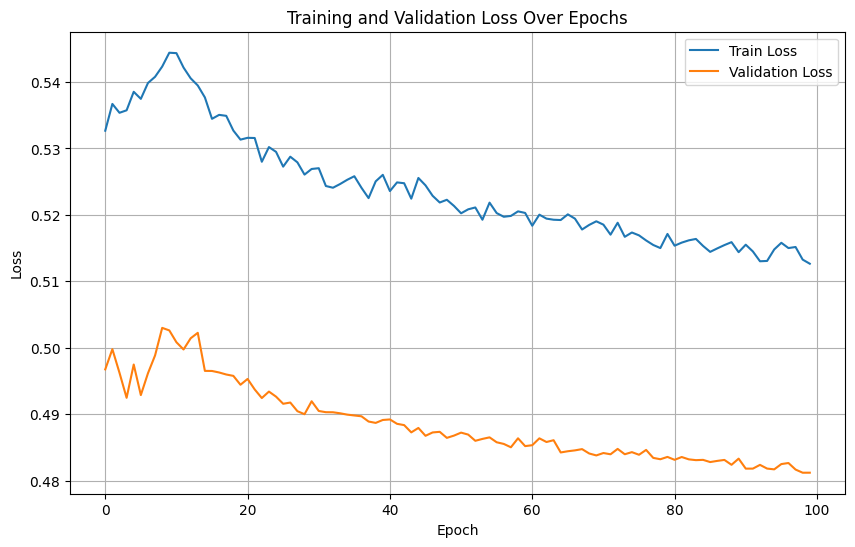

------------------------------

--- Evaluating on the held-out test set ---
Total number of test audio files: 61
Processed: 61 samples, skipped: 0 files.
Test dataset shape: X=(61, 107, 157, 1), y=(61, 7)

Final Test Set Performance:

Sample prediction probabilities:
Sample 1: True=Fear, Pred=Fear, Prob=[0.05014519 0.08871999 0.63915646 0.08405884 0.04077164 0.03264076
 0.06450718]
Sample 2: True=Fear, Pred=Fear, Prob=[0.02360119 0.04432657 0.80424356 0.04975204 0.0181668  0.03474399
 0.02516575]
Sample 3: True=Fear, Pred=Neutral, Prob=[0.05344935 0.12624545 0.25576815 0.35287562 0.03495805 0.04764599
 0.12905739]
Sample 4: True=Fear, Pred=Fear, Prob=[0.08713903 0.05417354 0.6883968  0.02369787 0.03195945 0.07980963
 0.03482365]
Sample 5: True=Fear, Pred=Fear, Prob=[0.00603846 0.00500489 0.95824444 0.01038523 0.00770146 0.00584783
 0.00677758]


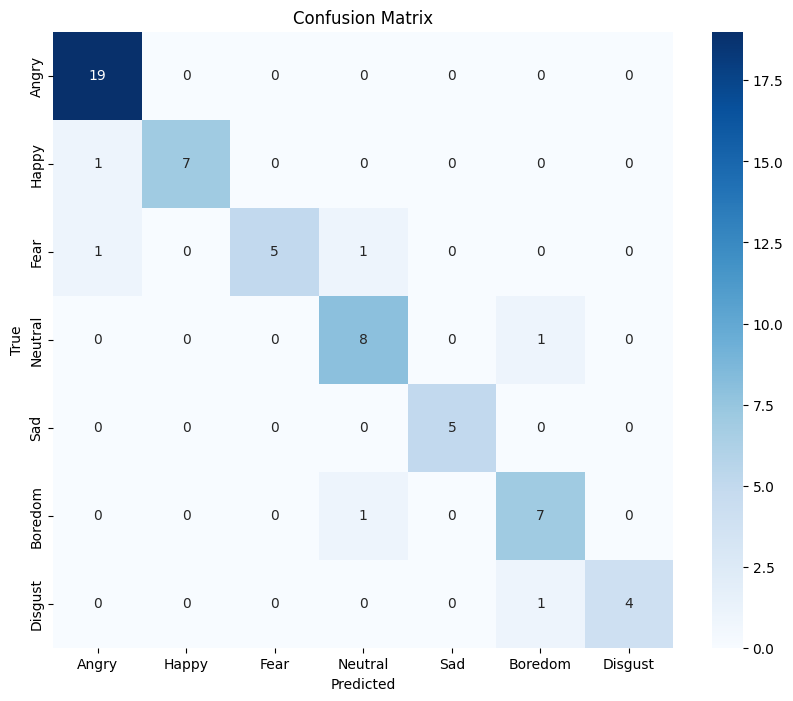


Classification Report:
              precision    recall  f1-score   support

       Angry       0.90      1.00      0.95        19
       Happy       1.00      0.88      0.93         8
        Fear       1.00      0.71      0.83         7
     Neutral       0.80      0.89      0.84         9
         Sad       1.00      1.00      1.00         5
     Boredom       0.78      0.88      0.82         8
     Disgust       1.00      0.80      0.89         5

    accuracy                           0.90        61
   macro avg       0.93      0.88      0.90        61
weighted avg       0.91      0.90      0.90        61


Evaluation metric formulas:
1. Precision = TP / (TP + FP)
   - TP (True Positives): Number of samples correctly predicted for a class.
   - FP (False Positives): Number of samples incorrectly predicted as that class.
2. Recall = TP / (TP + FN)
   - FN (False Negatives): Number of samples that belong to the class but were incorrectly predicted.
3. F1 Score = 2 * (Precision * R

In [ ]:
if __name__ == "__main__":
    # --- Bước 1: Tải và phân chia dữ liệu ---
    #root_folder = DATA_PATH
    #folders = [f for f in glob.glob(os.path.join(root_folder, "*")) if os.path.isdir(f)]
    #all_files = []
    #for folder in folders:
    #    files = glob.glob(os.path.join(folder, "**", "*.wav"), recursive=True)
    #    all_files.extend(files)

    #if not all_files:
    #    raise ValueError("No audio files found in the source directory.")
    
    #print(f"Total files found: {len(all_files)}")

    # Sử dụng hàm chia dữ liệu tùy chỉnh theo quy tắc mới
    #print("Splitting data based on custom prefix rule...")
    #data_train, data_test = split_data_by_prefix(all_files, emotion_map, test_ratio=0.1, output_excel_path='data_split_results.xlsx')
    
    print(f"Split data into {len(data_train)} training files and {len(data_test)} testing files.")
    print("-" * 30)

    # --- Bước 2: Huấn luyện (chỉ sử dụng data_train) ---
    print("Calculating GLOBAL_PITCH_PARAMS from training data...")
    GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE = calculate_global_pitch_params(data_train)
    print(f"GLOBAL_MEAN_PITCH: {GLOBAL_MEAN_PITCH:.4f}, GLOBAL_JITTER: {GLOBAL_JITTER:.4f}, GLOBAL_PITCH_SLOPE: {GLOBAL_PITCH_SLOPE:.4f}")

    y_raw = [emotion_map.get(os.path.basename(os.path.dirname(f))) for f in data_train if os.path.basename(os.path.dirname(f)) in emotion_map]
    y_raw_train = np.array(y_raw)
    print("Training label distribution:", Counter([EMOTIONS[i] for i in y_raw_train]))
    
    class_weights = compute_class_weight('balanced', classes=np.unique(y_raw_train), y=y_raw_train)
    class_weight_dict = dict(enumerate(class_weights))
    print("Class weights:", class_weight_dict)

    X, y = prepare_training_data(data_train, emotion_map, (GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE))
    print(f"Training data X shape: {X.shape}")

    scaler = StandardScaler()
    original_shape = X.shape
    X_2d = X.reshape(original_shape[0], -1)
    X_2d = scaler.fit_transform(X_2d)
    X = X_2d.reshape(original_shape)

    cnn_input_shape = (X.shape[1], X.shape[2], 1)
    print(f"Calculated CNN Input Shape: {cnn_input_shape}")
    
    cnn_model = build_cnn_2d(input_shape=cnn_input_shape)
    cnn_model, history, _, _ = train_and_evaluate_model(
        cnn_model, X, y,
        epochs=100,
        batch_size=16,
        checkpoint_path='best_cnn_2d_model.keras',
        class_weight=class_weight_dict,
        k_folds=5
    )
    
    # Lưu scaler và mô hình đã huấn luyện
    joblib.dump(scaler, 'final_scaler.pkl')
    cnn_model.save('final_model.keras')
    plot_loss_history(history)
    print("-" * 30)

    # --- Bước 3: Đánh giá cuối cùng (chỉ sử dụng data_test) ---
    print("\n--- Evaluating on the held-out test set ---")
    
    # Tải mô hình và scaler tốt nhất
    #best_model = tf.keras.models.load_model('final_model.keras')
    #scaler = joblib.load('final_scaler.pkl')

    # Chuẩn bị dữ liệu test
    X_test, y_test = prepare_test_data(data_test, emotion_map, (GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE))

    # Chuẩn hóa dữ liệu test với scaler đã fit từ dữ liệu training
    X_test_2d = X_test.reshape(X_test.shape[0], -1)
    X_test_2d = scaler.transform(X_test_2d) # Chỉ dùng TRANSFORM
    X_test = X_test_2d.reshape(X_test.shape)
    
    # Đánh giá hiệu năng cuối cùng
    print("\nFinal Test Set Performance:")
    evaluate_model(cnn_model, X_test, y_test)

    # --- Bước 4: Dự đoán trên các file test đơn lẻ ---
    print("\n--- Predictions on individual test files ---")
    for test_path in data_test[:5]: # Dự đoán trên 5 file đầu tiên của tập test
        predicted_emotion = predict_emotion(test_path, cnn_model, scaler, (GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE))
        true_emotion_label = EMOTIONS[emotion_map.get(os.path.basename(os.path.dirname(test_path)))]
        print(f"File: {os.path.basename(test_path)} | True: {true_emotion_label} | Predicted: {predicted_emotion}")